## Step - 1 Understanding the problem
- It is hard to determine the prices of houses where you don't live or where you want to invest in, hence we are trying to create a model
which can predict and tell us the price of a house based on location, number of rooms, median income etc.

# What would a successful model look like ?
- A successful model should be able to accurately determine the price of a house in california based on location, number of rooms, ocean proximity etc.

# Step - 2 Gathering the data
- Thanks to https://www.kaggle.com/datasets/camnugent/california-housing-prices we have already have our data with us, with this data we can
train our model efficiently.

## Step - 3 Exploring and visualizing the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


It seems like that houses near bay are more expensive then the houses on inland, lets visualize it to be more sure

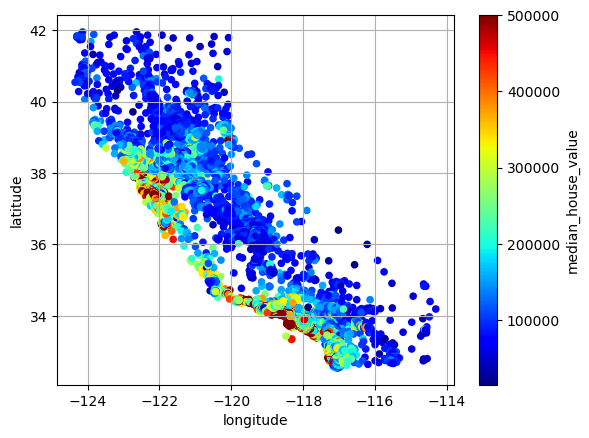

In [5]:
df.plot(kind="scatter", x="longitude", y="latitude", cmap="jet", c="median_house_value", grid=True)
plt.savefig("fig_1.jpg")
plt.show()

Because our data is of good quality our scatter plot actually resembles the california's map, hence we can confidently say that yes
the houses near bay are indeed more expensive as comapred to other houses. 
With this in mind we will be more careful when scaling our dataset while training our model.

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

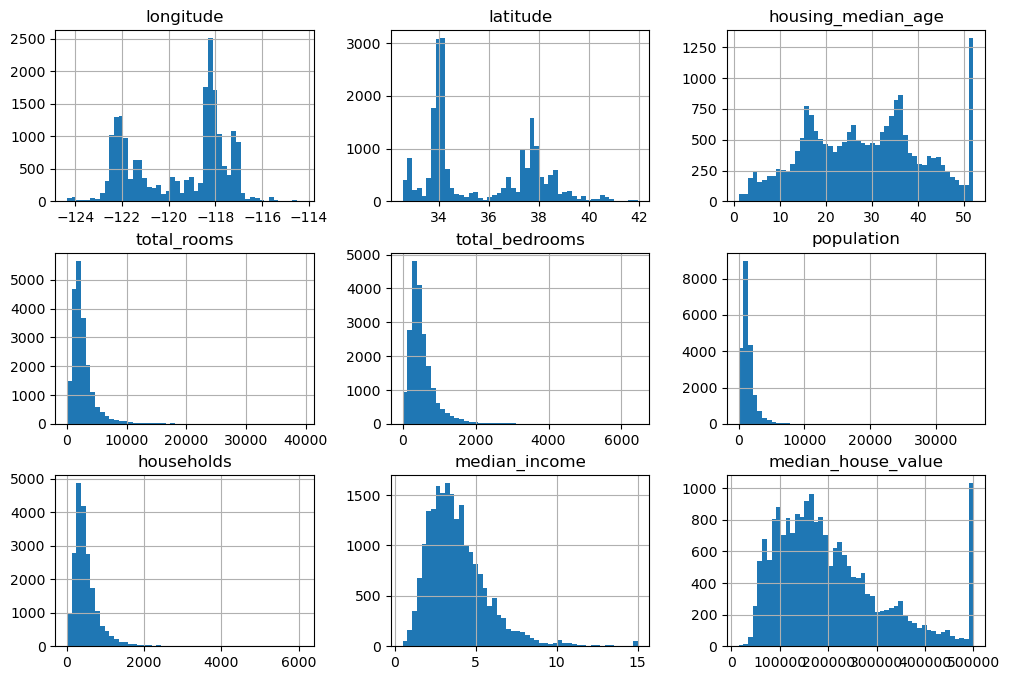

In [7]:
df.hist(bins=50, figsize=(12,8))

In [8]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


It seems like there are some null values in total_bedrooms column, we will have to use sklearn.impute's SimpleImputer to get
rid of them for now lets check how many null values we have in total

In [10]:
df.isnull().sum() 

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

With this now we have a gist about what we are dealing with although there is still a lot factors to weigh in like the values in our data are
very far from each other or in other words the values differ from each other by huge margin which could be a huge problem as sklearn models 
give higer importance to values which are larger but for now lets move on to the next step

## Step - 4 Preparing the data
- We will now split the data in 80 - 20 meaning that the 80% of the data will be used to train the model and rest 20% of the model will be used to
test the model.
- We will be using sklearn's StratifiedShuffleSplit to do that

In [11]:
def shuffle_and_split(data, test_ratio):
    np.random.seed(42)
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(test_ratio * len(data))
    train_indices = shuffled_indices[test_set_size:]
    test_indices = shuffled_indices[:test_set_size]
    return data.loc[train_indices], data.loc[test_indices]

train_set, test_set = shuffle_and_split(df, 0.2)

In [12]:
test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0,<1H OCEAN
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0,NEAR OCEAN
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0,<1H OCEAN
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0,INLAND


we can use this code to split our data but there is an issue with this, it doesn't necessarily split our data correctly meaning it is not necessary
that this code splits our data in a way which will contain some values of all columns, this train set can have all the data of the same columns as 
it was randomly taken out, hence to avoid this problem we will use sklearn's StratifiedShuffleSplit

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

we will also create a new column called income_cat which will help ensure that all the values of each type of data is being sent to our test set

In [14]:
df["income_cat"] = pd.cut(df["median_income"], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5])
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    train_set = df.loc[train_index]
    test_set = df.loc[test_index]

<Axes: xlabel='income_cat'>

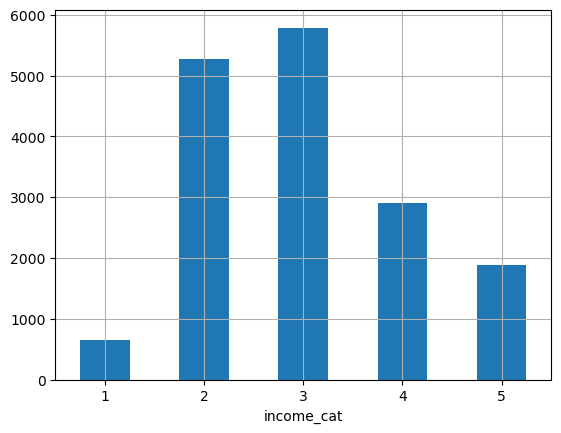

In [15]:
# Checking if our data is correctly split
train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

<Axes: xlabel='income_cat'>

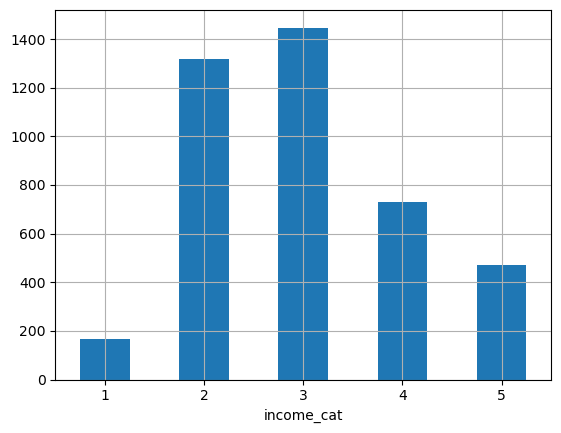

In [16]:
test_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

As we can see the shape of the two diagrams is almost identical hence we can say that the data has been split correctly in the two sets

In [17]:
# We no longer need the ["income_cat"] column hence we will remove it
for sett in (df, train_set, test_set):
    sett.drop("income_cat", axis=1, inplace=True)

We will now this test set and will only call it during the testing of the model or at the end of the project to avoid data snooping bias.

In [18]:
test_set.to_csv("Testing_data.csv", index=False)

Now comes time for the preprocessing phase, now we will create pipelines to clean our data, handle missing values, handle categorical values like
in ocean_proximity column and scaling our data so that values don't differ as much as they do now.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [20]:
# First we will split the features and labels
housing = train_set.copy()
housing_labels = train_set["median_house_value"].copy()
housing = housing.drop("median_house_value", axis=1)

In [21]:
num_attrs = housing.drop("ocean_proximity", axis=1).columns.tolist() # we need to give column names
cat_attrs = ["ocean_proximity"]

In [22]:
# Creating the pipelines
# For numerical values
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
     ])
# For categorical Values
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
# Full pipeline
full_pipeline = ColumnTransformer([
    ("nums", num_pipeline, num_attrs),
    ("cats", cat_pipeline, cat_attrs)
])

In [23]:
# Applying the full pipeline to our data
housing_prepared = full_pipeline.fit_transform(housing)

Now our training data is completely ready to be used for training our model, we can now move to the next step.

## Step - 5 Selecting the right model and training it
- We have a lot of options which we can but for our dataset the best candidates looks like Linear Regression model, Decision Tree Regressor model,
RandomForest Regressor model.
- Hence we will train all three models and check which one gives the best results

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [25]:
# For linear regression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
lin_predicts = lin_reg.predict(housing_prepared)

# For Decision Tree Regressor
dec_reg = DecisionTreeRegressor()
dec_reg.fit(housing_prepared, housing_labels)
dec_predicts = dec_reg.predict(housing_prepared)

# For Random Forest Regressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
forest_predicts = forest_reg.predict(housing_prepared)

Now that models have been trained we will now compare them by error measuring methods of sklearn

In [26]:
from sklearn.metrics import root_mean_squared_error

In [27]:
lin_rmse = root_mean_squared_error(housing_labels, lin_predicts)
dec_rmse = root_mean_squared_error(housing_labels, dec_predicts) # Overfitting Indications
forest_rmse = root_mean_squared_error(housing_labels, forest_predicts)

print(lin_rmse)
print(dec_rmse)
print(forest_rmse)

69050.56219504567
0.0
18378.801652684


The root_mean_squared_error of decision tree regressor gives strong impressions of overfitting. So to chech we will use sklearn's cross_val_score

In [28]:
from sklearn.model_selection import cross_val_score

In [29]:
lin_rmses = -cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
dec_rmses = -cross_val_score(dec_reg, housing_prepared, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
forest_rmses = -cross_val_score(forest_reg, housing_prepared, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

print("For Linear Regressor:")
print(pd.Series(lin_rmses).describe())
print("For Decision Tree Regressor:")
print(pd.Series(dec_rmses).describe())
print("For Random Forest Regressor:")
print(pd.Series(forest_rmses).describe())

For Linear Regressor:
count       10.000000
mean     69204.322755
std       2500.382157
min      65318.224029
25%      67124.346106
50%      69404.658178
75%      70697.800632
max      73003.752739
dtype: float64
For Decision Tree Regressor:
count       10.000000
mean     69409.973919
std       2347.969495
min      65587.800367
25%      67889.377778
50%      70276.266468
75%      70862.230950
max      72646.994582
dtype: float64
For Random Forest Regressor:
count       10.000000
mean     49421.021807
std       2144.442709
min      46236.361441
25%      47884.575316
50%      49202.342839
75%      50883.584899
max      53022.177302
dtype: float64


With this it is clear that Random Forest Regressor is the best model to use for our dataset

## Step - 6 Saving our work and showing result
- Now that our model is selected, we will create a python file and repeat these steps there with only difference being that we will use joblib to save our model and pipeline. There will be no explanation in the python file.
- After this we will use our testing_set which we saved earlier to compare our model's predictions with the actual answers.
- We will also visualize our data so that we can see our predictions clearly

In [30]:
import matplotlib.pyplot as plt
predictions = pd.read_csv("Predictions.csv")

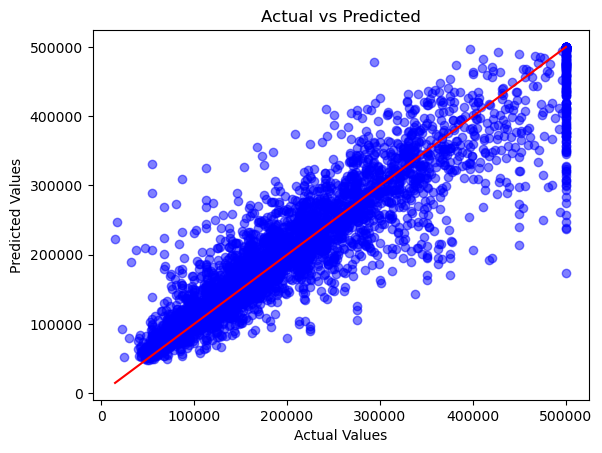

In [32]:
actual = test_set["median_house_value"].reset_index(drop=True) 
pred = predictions["median_house_value"].reset_index(drop=True)

plt.scatter(actual, pred, color="blue", alpha=0.5)

# add diagonal perfect prediction line
import numpy as np
line = np.linspace(actual.min(), actual.max(), 100)
plt.plot(line, line, color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.savefig("figure_comparision.jpg")
plt.show()

## THANK YOU